<a href="https://colab.research.google.com/github/azcsprof/ASU-CSE475-SS25/blob/Unit-3-Lab-1/Unit_3_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

In [2]:
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
class CNN(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size, padding=kernel_size // 2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size, padding=kernel_size // 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.out = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        return self.out(x)

In [4]:
def run_training_callback(b):
    clear_output(wait=True)
    display(lr_slider, batch_slider, epoch_slider, kernel_dropdown, run_button)

    # Get hyperparameters
    lr = lr_slider.value
    batch_size = batch_slider.value
    epochs = epoch_slider.value
    kernel_size = kernel_dropdown.value

    print(f"Training with LR={lr}, Batch={batch_size}, Epochs={epochs}, Kernel={kernel_size}")

    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load CIFAR-10
    full_train = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_data = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

    train_subset, _ = random_split(full_train, [10000, len(full_train)-10000])
    test_subset, _ = random_split(test_data, [2000, len(test_data)-2000])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CNN(kernel_size=kernel_size).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = torch.argmax(model(inputs), dim=1).cpu()
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc = correct / total
        val_accuracies.append(acc)
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={acc:.4f}")

    # Plot loss and accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, marker='o')
    ax1.set_title("Training Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax2.plot(val_accuracies, marker='o')
    ax2.set_title("Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

    # Store model and test data globally
    global latest_model, latest_test_data
    latest_model = model
    latest_test_data = test_subset

Epoch 2: Loss=1.8267, Val Acc=0.3770
Epoch 3: Loss=1.7056, Val Acc=0.4185
Epoch 4: Loss=1.6112, Val Acc=0.4450
Epoch 5: Loss=1.5468, Val Acc=0.4525


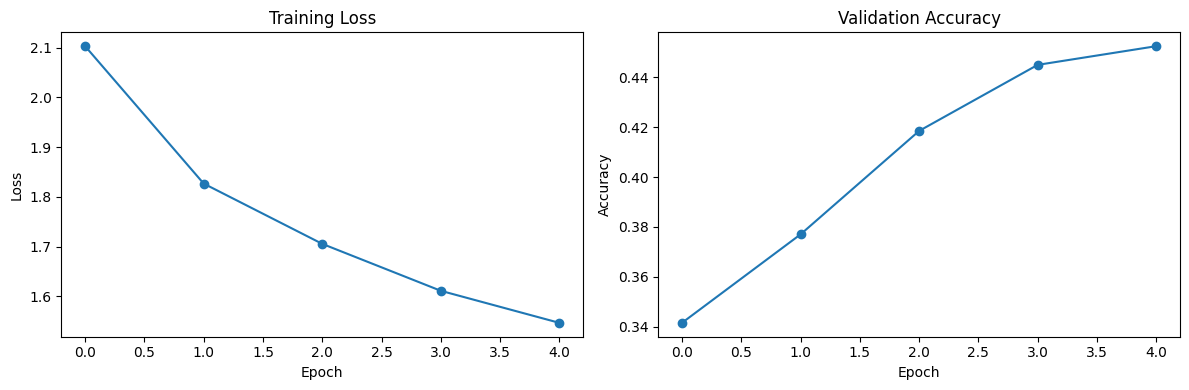

FloatSlider(value=0.0001, description='LR', max=0.01, min=1e-05, step=0.0001)

IntSlider(value=32, description='Batch', max=128, min=8, step=8)

IntSlider(value=5, description='Epochs', max=20, min=1)

Dropdown(description='Kernel:', index=1, options=(2, 3, 4), value=3)

Button(button_style='success', description='Run Training', style=ButtonStyle())

In [9]:
# Sliders and dropdowns
lr_slider = widgets.FloatSlider(value=0.0001, min=1e-5, max=0.01, step=1e-4, description="LR")
batch_slider = widgets.IntSlider(value=32, min=8, max=128, step=8, description="Batch")
epoch_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description="Epochs")
kernel_dropdown = widgets.Dropdown(options=[2, 3, 4], value=3, description="Kernel:")

# Run training button
run_button = widgets.Button(description="Run Training", button_style='success')

# Display controls
display(lr_slider, batch_slider, epoch_slider, kernel_dropdown, run_button)

run_button.on_click(run_training_callback)

Button(button_style='info', description='Next Batch', style=ButtonStyle())

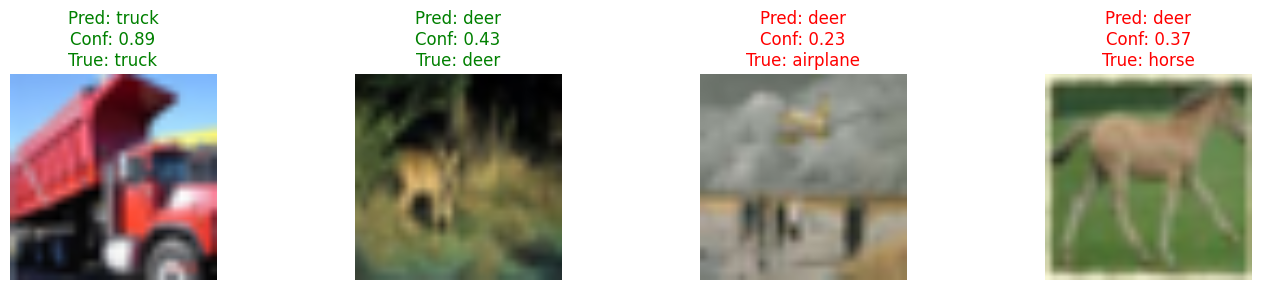

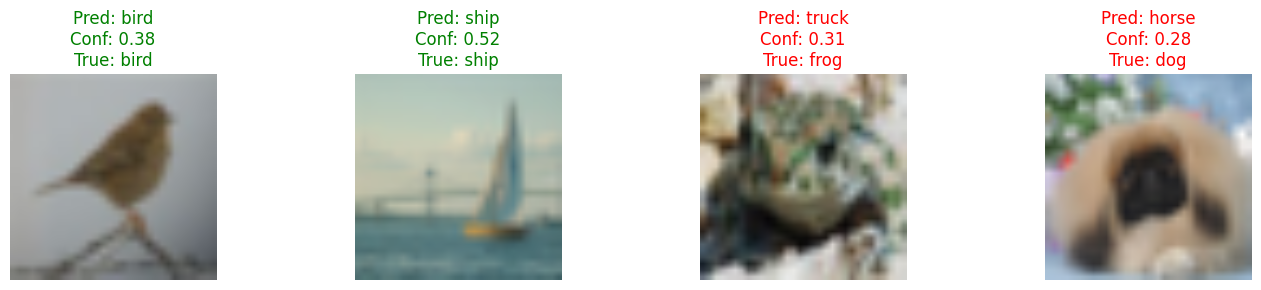

In [10]:

def display_predictions():
    model = latest_model
    test_subset = latest_test_data
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    dataloader = DataLoader(test_subset, batch_size=32, shuffle=True)
    images, labels = next(iter(dataloader))
    images = images.to(device)
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    # Find 2 correct + 2 incorrect
    correct_idx = (preds == labels.to(device)).nonzero(as_tuple=True)[0][:2]
    wrong_idx = (preds != labels.to(device)).nonzero(as_tuple=True)[0][:2]
    chosen = torch.cat([correct_idx, wrong_idx])

    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    for i, idx in enumerate(chosen):
        img = images[idx].cpu().permute(1, 2, 0) * 0.5 + 0.5  # Denormalize
        pred_class = cifar_classes[preds[idx]]
        true_class = cifar_classes[labels[idx]]
        conf = probs[idx][preds[idx]].item()
        color = 'green' if preds[idx] == labels[idx].to(device) else 'red'
        axes[i].imshow(img.numpy(), interpolation='bilinear')  # Smoother
        axes[i].set_title(f"Pred: {pred_class}\nConf: {conf:.2f}\nTrue: {true_class}", color=color)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

# Create a "Next Batch" button
next_button = widgets.Button(description="Next Batch", button_style='info')
next_button.on_click(lambda b: display_predictions())
display(next_button)

# Optionally run once at start
display_predictions()